In [1]:
import geopandas as gpd
import pandas as pd


from shapely.ops import unary_union, linemerge
from shapely.geometry import Point, LineString, MultiLineString
from shapely.geometry import mapping


import networkx as nx


import folium
from folium import Map, GeoJson


import json
import mapillary as mly




### Berlin einlesen für Proof of concept

<Axes: >

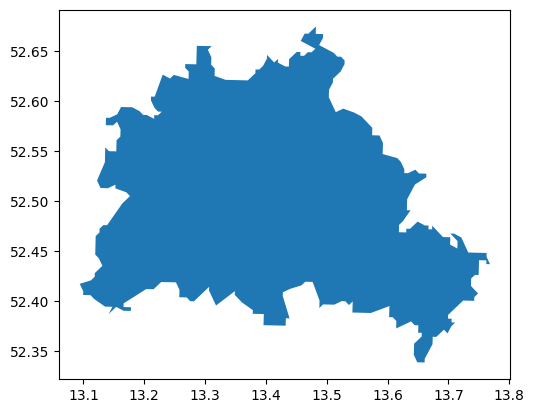

In [2]:
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
bland_fil=bland[bland["id"].isin(["DE-BE"])]
bland_fil.plot()

### netzwerk einlesen

In [4]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_almostall_highways_germany_250528.geojson.gz")

crossings=gpd.read_file("../preprocessing/processed_osm_files/processed_crossings_germany_250528.geojson.gz")



In [5]:
## nur Berlin
crossings_in_bl = gpd.clip(crossings, bland_fil)
crossings_in_bl 

,other_tags,geometry
400560,"""crossing""=>""unmarked"",""crossing:markings""=>""n...",POINT (13.37077 52.40831)
393962,"""highway""=>""crossing""",POINT (13.33564 52.40884)
393958,"""highway""=>""crossing""",POINT (13.33847 52.40991)
393960,"""highway""=>""crossing""",POINT (13.3378 52.41053)
393959,"""highway""=>""crossing""",POINT (13.33773 52.41056)
...,...,...
327660,"""button_operated""=>""yes"",""crossing""=>""traffic_...",POINT (13.43157 52.62437)
10672,"""crossing""=>""unmarked"",""crossing:island""=>""no""...",POINT (13.4254 52.61303)
367418,"""crossing""=>""unmarked"",""crossing:island""=>""no""...",POINT (13.41631 52.60803)
367417,"""crossing""=>""unmarked"",""crossing:island""=>""no""...",POINT (13.41412 52.60907)


<Axes: >

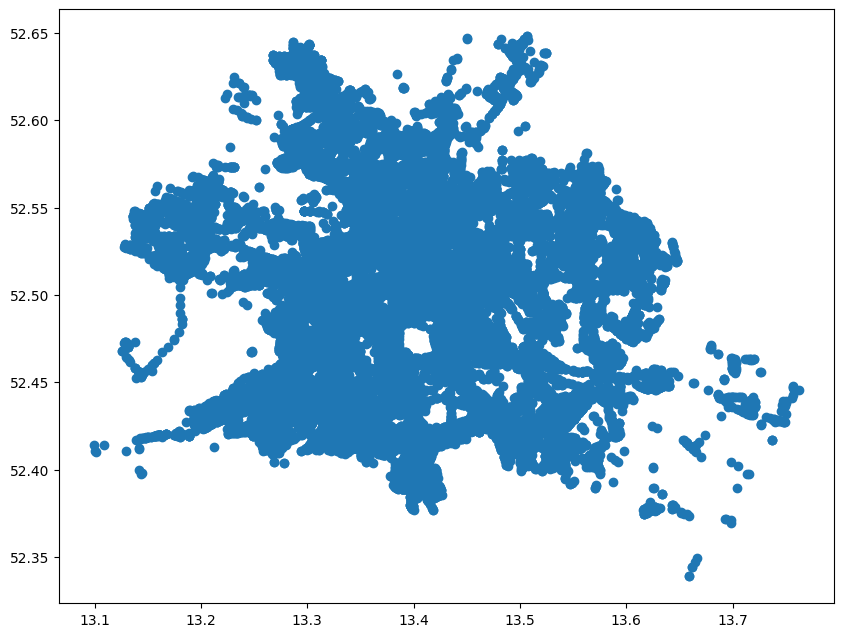

In [6]:
crossings_in_bl.plot( figsize=(10, 10))

In [7]:
# mapillary map feature data: traffic signs einlesen

In [8]:
mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_berlin_2025-06-07.parquet")
mapillary_trafficsigns

,geometry,first_seen_at,id,last_seen_at,value
0,POINT (13.09673 52.41332),2015-11-18,1391186787929268,2015-11-18,information--general-directions--g1
1,POINT (13.10878 52.41408),2015-11-18,1178445959261416,2016-03-25,warning--wild-animals--g1
2,POINT (13.0971 52.41321),2017-06-25,1696373427217755,2024-05-09,regulatory--no-parking--g1
3,POINT (13.10394 52.40669),2019-06-11,395689434851066,2019-06-11,regulatory--no-parking--g1
4,POINT (13.0961 52.41325),2015-11-18,483876509493610,2015-11-18,regulatory--maximum-speed-limit-50--g1
...,...,...,...,...,...
348888,POINT (13.75132 52.41046),2020-05-09,940194036739663,2021-09-14,regulatory--keep-right--g1
348889,POINT (13.75013 52.40777),2019-06-30,1260813321017851,2021-09-14,regulatory--shared-path-pedestrians-and-bicycl...
348890,POINT (13.75327 52.41479),2017-05-14,304906801194963,2023-04-10,regulatory--no-parking--g1
348891,POINT (13.75086 52.41488),2022-01-10,934980713814996,2022-01-10,regulatory--priority-road--g1


In [18]:
# Tempo 30 Schilder in Berlin
mapillary_trafficsigns_cross=mapillary_trafficsigns[mapillary_trafficsigns.value=="information--pedestrians-crossing--g1"]
mapillary_trafficsigns_cross


,geometry,first_seen_at,id,last_seen_at,value
318,POINT (13.13287 52.52865),2019-10-06,618306472420326,2024-09-18,information--pedestrians-crossing--g1
365,POINT (13.13274 52.52862),2019-10-06,1216829958787099,2024-09-18,information--pedestrians-crossing--g1
391,POINT (13.13284 52.52855),2020-07-08,618295452421428,2020-07-08,information--pedestrians-crossing--g1
400,POINT (13.13287 52.52871),2019-10-06,1216926982110730,2024-09-18,information--pedestrians-crossing--g1
516,POINT (13.1268 52.46862),2019-07-27,2861767130751606,2019-07-27,information--pedestrians-crossing--g1
...,...,...,...,...,...
348313,POINT (13.71867 52.43148),2016-02-17,296240705301650,2016-02-17,information--pedestrians-crossing--g1
348348,POINT (13.71853 52.43144),2016-02-17,296471335278587,2016-02-17,information--pedestrians-crossing--g1
348447,POINT (13.71854 52.43143),2016-02-17,296622831930104,2016-02-17,information--pedestrians-crossing--g1
348463,POINT (13.71862 52.43144),2016-02-17,296220305303690,2016-02-17,information--pedestrians-crossing--g1


In [33]:
# Baustellen ausschließen (werden aber vermutlich auch "gute" aussprtiert)

from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

df_6months = mapillary_trafficsigns[
    mapillary_trafficsigns.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 6, axis=1)
]
df_6months_crossing=df_6months[df_6months.value == "information--pedestrians-crossing--g1"]

<Axes: >

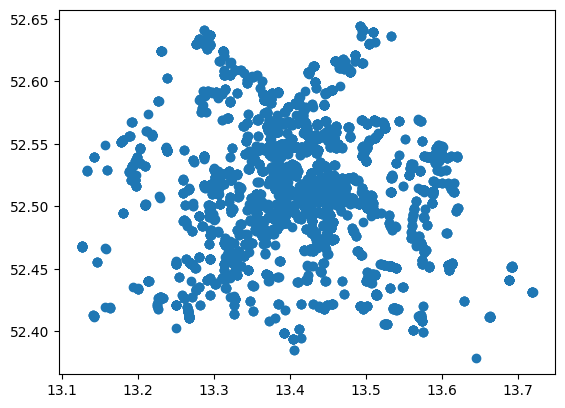

In [19]:
mapillary_trafficsigns_cross.plot()

In [20]:
mapillary_trafficsigns_cross.explore(
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at"]
)

In [22]:
mapillary_trafficsigns_cross_buffered = mapillary_trafficsigns_cross.to_crs(25833).copy()
mapillary_trafficsigns_cross_buffered["geometry"] = mapillary_trafficsigns_cross_buffered.geometry.buffer(40)
mapillary_trafficsigns_cross_buffered = mapillary_trafficsigns_cross_buffered.to_crs(mapillary_trafficsigns_cross.crs)
mapillary_trafficsigns_cross_buffered

,geometry,first_seen_at,id,last_seen_at,value
318,"POLYGON ((13.13346 52.52866, 13.13346 52.52862...",2019-10-06,618306472420326,2024-09-18,information--pedestrians-crossing--g1
365,"POLYGON ((13.13333 52.52863, 13.13333 52.52859...",2019-10-06,1216829958787099,2024-09-18,information--pedestrians-crossing--g1
391,"POLYGON ((13.13342 52.52856, 13.13342 52.52853...",2020-07-08,618295452421428,2020-07-08,information--pedestrians-crossing--g1
400,"POLYGON ((13.13346 52.52872, 13.13346 52.52869...",2019-10-06,1216926982110730,2024-09-18,information--pedestrians-crossing--g1
516,"POLYGON ((13.12738 52.46863, 13.12738 52.46859...",2019-07-27,2861767130751606,2019-07-27,information--pedestrians-crossing--g1
...,...,...,...,...,...
348313,"POLYGON ((13.71926 52.43149, 13.71925 52.43145...",2016-02-17,296240705301650,2016-02-17,information--pedestrians-crossing--g1
348348,"POLYGON ((13.71912 52.43145, 13.71911 52.43141...",2016-02-17,296471335278587,2016-02-17,information--pedestrians-crossing--g1
348447,"POLYGON ((13.71913 52.43144, 13.71913 52.4314,...",2016-02-17,296622831930104,2016-02-17,information--pedestrians-crossing--g1
348463,"POLYGON ((13.71921 52.43145, 13.71921 52.43141...",2016-02-17,296220305303690,2016-02-17,information--pedestrians-crossing--g1


In [26]:
not_intersected = gpd.sjoin(
    mapillary_trafficsigns_cross_buffered, 
    crossings_in_bl, 
    how="left", 
    predicate="intersects"
)
not_intersected = not_intersected[not_intersected["index_right"].isna()]


In [27]:
not_intersected

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags
516,"POLYGON ((13.12738 52.46863, 13.12738 52.46859...",2019-07-27,2861767130751606,2019-07-27,information--pedestrians-crossing--g1,NaN,NaN
2051,"POLYGON ((13.15822 52.46576, 13.15822 52.46572...",2020-10-12,2147828275372649,2020-10-12,information--pedestrians-crossing--g1,NaN,NaN
2056,"POLYGON ((13.15771 52.46664, 13.15771 52.46661...",2020-10-12,156854063078065,2020-10-12,information--pedestrians-crossing--g1,NaN,NaN
2934,"POLYGON ((13.14308 52.41161, 13.14308 52.41157...",2023-12-12,1181080206185637,2023-12-12,information--pedestrians-crossing--g1,NaN,NaN
2944,"POLYGON ((13.14188 52.41318, 13.14188 52.41315...",2024-09-11,1204211260790634,2025-03-26,information--pedestrians-crossing--g1,NaN,NaN
...,...,...,...,...,...,...,...
336584,"POLYGON ((13.58934 52.52025, 13.58934 52.52021...",2022-02-05,1190632605586491,2022-02-05,information--pedestrians-crossing--g1,NaN,NaN
336979,"POLYGON ((13.58948 52.52001, 13.58947 52.51997...",2022-02-05,1190632642253154,2022-02-05,information--pedestrians-crossing--g1,NaN,NaN
340969,"POLYGON ((13.60215 52.54735, 13.60215 52.54731...",2018-04-07,3012876102327981,2018-04-07,information--pedestrians-crossing--g1,NaN,NaN
346187,"POLYGON ((13.64512 52.37881, 13.64512 52.37878...",2020-09-02,303616667881694,2020-09-02,information--pedestrians-crossing--g1,NaN,NaN


In [30]:
#not_intersected.explore()

In [29]:
not_intersected_recent = not_intersected[not_intersected["last_seen_at"] > "2020-01-01"]
not_intersected_recent

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags
2051,"POLYGON ((13.15822 52.46576, 13.15822 52.46572...",2020-10-12,2147828275372649,2020-10-12,information--pedestrians-crossing--g1,NaN,NaN
2056,"POLYGON ((13.15771 52.46664, 13.15771 52.46661...",2020-10-12,156854063078065,2020-10-12,information--pedestrians-crossing--g1,NaN,NaN
2934,"POLYGON ((13.14308 52.41161, 13.14308 52.41157...",2023-12-12,1181080206185637,2023-12-12,information--pedestrians-crossing--g1,NaN,NaN
2944,"POLYGON ((13.14188 52.41318, 13.14188 52.41315...",2024-09-11,1204211260790634,2025-03-26,information--pedestrians-crossing--g1,NaN,NaN
2982,"POLYGON ((13.14179 52.41314, 13.14179 52.41311...",2025-02-05,1134781877865355,2025-02-05,information--pedestrians-crossing--g1,NaN,NaN
...,...,...,...,...,...,...,...
335802,"POLYGON ((13.59555 52.54905, 13.59555 52.54901...",2021-12-19,5217057521654963,2022-11-05,information--pedestrians-crossing--g1,NaN,NaN
336584,"POLYGON ((13.58934 52.52025, 13.58934 52.52021...",2022-02-05,1190632605586491,2022-02-05,information--pedestrians-crossing--g1,NaN,NaN
336979,"POLYGON ((13.58948 52.52001, 13.58947 52.51997...",2022-02-05,1190632642253154,2022-02-05,information--pedestrians-crossing--g1,NaN,NaN
346187,"POLYGON ((13.64512 52.37881, 13.64512 52.37878...",2020-09-02,303616667881694,2020-09-02,information--pedestrians-crossing--g1,NaN,NaN


In [40]:
# Baustellen ausschließen (werden aber vermutlich auch "gute" aussprtiert)

from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

not_intersected_recent_36months = not_intersected_recent[
    not_intersected_recent.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 36, axis=1)
]

In [42]:
not_intersected_recent_36months.explore(tiles="CartoDB positron")

---> Es ist einfach zu anfällig für Baustellen, die nicht mehr existieren.

In [ ]:
################################

In [108]:
## retrieve the image ID for the map features

In [ ]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress


# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None

df_6months_30_buffered_recent_false["image_id"] = df_6months_30_buffered_recent_false["id"].apply(get_image_id)


Requesting GET to https://graph.mapillary.com/1696254303896334/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images
Response 200 OK received in 334ms
Requesting GET to https://graph.mapillary.com/909700103151725/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images
Response 200 OK received in 528ms
Requesting GET to https://graph.mapillary.com/2600714330230139/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images
Response 200 OK received in 419ms
Requesting GET to https://graph.mapillary.com/239352242174087/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images
Response 200 OK received in 555ms
Requesting GET to https://graph.mapillary.com/239352312174080/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images
Response 200 OK received in 370ms
Requesting GET to https://graph.mapillary.com/837077643825545/?fields=first_seen_at,last_seen_at,object_value,object_type,geometry,images


/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [110]:
df_6months_30_buffered_recent_false

,geometry,first_seen_at,id,last_seen_at,value,has_30_intersection,image_id
16,"POLYGON ((13.09621 52.41317, 13.09621 52.41315...",2017-06-25,1696254303896334,2024-05-09,regulatory--maximum-speed-limit-30--g1,False,2867261640181054
769,"POLYGON ((13.12186 52.44272, 13.12185 52.4427,...",2015-10-03,909700103151725,2025-04-06,regulatory--maximum-speed-limit-30--g1,False,875171593046170
9468,"POLYGON ((13.19396 52.43379, 13.19396 52.43377...",2017-03-19,2600714330230139,2025-02-05,regulatory--maximum-speed-limit-30--g1,False,789603061927825
25677,"POLYGON ((13.26153 52.43611, 13.26153 52.43609...",2023-06-12,239352242174087,2024-07-31,regulatory--maximum-speed-limit-30--g1,False,3416161058650342
26070,"POLYGON ((13.26167 52.43609, 13.26167 52.43606...",2023-06-12,239352312174080,2024-07-31,regulatory--maximum-speed-limit-30--g1,False,810244850235708
...,...,...,...,...,...,...,...
346699,"POLYGON ((13.64959 52.37586, 13.64959 52.37584...",2017-05-14,289185886209346,2024-10-16,regulatory--maximum-speed-limit-30--g1,False,823553691912666
347444,"POLYGON ((13.70387 52.45957, 13.70387 52.45954...",2023-11-29,332942332936103,2025-02-11,regulatory--maximum-speed-limit-30--g1,False,384752730760330
347448,"POLYGON ((13.70435 52.46645, 13.70435 52.46643...",2023-05-28,1895952417444075,2024-08-29,regulatory--maximum-speed-limit-30--g1,False,560538692940983
347486,"POLYGON ((13.70441 52.4667, 13.70441 52.46668,...",2023-05-28,1895952414110742,2024-08-29,regulatory--maximum-speed-limit-30--g1,False,560538692940983


In [111]:
sc4_poly=df_6months_30_buffered_recent_false.copy()


In [112]:
sc4_poly.to_file("scenario4_tempo30missing_polys.fgb", driver="FlatGeobuf")

In [113]:
sc4_centroids = sc4_poly.copy()
sc4_centroids=sc4_centroids.to_crs(25832)
sc4_centroids["geometry"] = sc4_centroids.geometry.centroid
sc4_centroids=sc4_centroids.to_crs(4326)

sc4_centroids

,geometry,first_seen_at,id,last_seen_at,value,has_30_intersection,image_id
16,POINT (13.09577 52.41317),2017-06-25,1696254303896334,2024-05-09,regulatory--maximum-speed-limit-30--g1,False,2867261640181054
769,POINT (13.12141 52.44272),2015-10-03,909700103151725,2025-04-06,regulatory--maximum-speed-limit-30--g1,False,875171593046170
9468,POINT (13.19352 52.43378),2017-03-19,2600714330230139,2025-02-05,regulatory--maximum-speed-limit-30--g1,False,789603061927825
25677,POINT (13.26109 52.43611),2023-06-12,239352242174087,2024-07-31,regulatory--maximum-speed-limit-30--g1,False,3416161058650342
26070,POINT (13.26123 52.43608),2023-06-12,239352312174080,2024-07-31,regulatory--maximum-speed-limit-30--g1,False,810244850235708
...,...,...,...,...,...,...,...
346699,POINT (13.64915 52.37586),2017-05-14,289185886209346,2024-10-16,regulatory--maximum-speed-limit-30--g1,False,823553691912666
347444,POINT (13.70343 52.45957),2023-11-29,332942332936103,2025-02-11,regulatory--maximum-speed-limit-30--g1,False,384752730760330
347448,POINT (13.70391 52.46645),2023-05-28,1895952417444075,2024-08-29,regulatory--maximum-speed-limit-30--g1,False,560538692940983
347486,POINT (13.70397 52.4667),2023-05-28,1895952414110742,2024-08-29,regulatory--maximum-speed-limit-30--g1,False,560538692940983


In [114]:
sc4_centroids.to_file("scenario4_tempo30missing_points.fgb", driver="FlatGeobuf")

In [115]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [116]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario4_tempo30missing_points.fgb",
    polys_fgb="scenario4_tempo30missing_polys.fgb",
    output_pmtiles="scenario4_tempo30missing.pmtiles",
    layer_name="scenario4"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
157 features, 7354 bytes of geometry and attributes, 10416 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8797/5375  
detected indexed FlatGeobuf: assigning feature IDs by sequence
157 features, 37754 bytes of geometry and attributes, 10404 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17606/10732  


✅ Combined PMTiles created
